In [1]:
import os
import sys
import glob
from pathlib import Path
from astropy.io import fits
import numpy as np
from numpy import savetxt
import matplotlib.pyplot as plt
from PyAstronomy import pyasl
from scipy.interpolate import interp1d
from astropy import units as u
from astropy.coordinates import SkyCoord
#install dustmaps from https://github.com/gregreen/dustmaps
from dustmaps.sfd import SFDQuery
import pandas as pd
from astropy.table import Table

In [2]:
path = '/home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/Tex_spectra/'

if (os.path.exists(path) == True):
    print('Folder for HII Galaxies tex format \n')
else:
    print(f'Folder for HII Galaxies tex format created ({path}) \n')
    os.mkdir(path)

Folder for HII Galaxies tex format 



In [3]:
spec_list = os.listdir(path[:-12])
spec_list.remove('Tex_spectra')

In [5]:
def sdss_dust_correction(NAME):
    hdu = fits.open('/home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/'+NAME)
    data = hdu[0].data
    ##############################################################
    #Read the header
    
    zz = hdu[0].header['Z']
    RA = hdu[0].header['RA']
    DEC = hdu[0].header['DEC']
    
    c = SkyCoord(ra=RA*u.degree, dec=DEC*u.degree, frame='icrs')
    c.galactic
    
    sfd = SFDQuery()
    ebv01 = sfd(c.galactic)
    
    ##############################################################
    #Read the spectra, flux and wavelength
    
    flux = data[0]
    wav00 = hdu[0].header['COEFF0']
    wavdiff = hdu[0].header['COEFF1']

    hdu.close()
    
    waveair = 10**(wav00 + wavdiff*np.arange(len(flux)))
    
    waveobs = waveair/(1.0+2.735182E-4+131.4182/(waveair)**2 +2.76249E8/(waveair)**4)
    
    ##############################################################
    #redshift correction
    
    wave = waveobs/(1.0+zz)
    
    ##############################################################
    #Unredding the spectra
    
    fluxUnred = pyasl.unred(wave, flux, ebv=ebv01, R_V=3.1)
    
    ##############################################################
    #cosmoiogical flux corrextion
    
    flux_final = fluxUnred*(1.0+zz)**3
    
    ##############################################################
    #Change the wavelength to starlight input
    
    wave_in = int(wave[2])             #initial wavelength
    wave_fin = int(wave[len(wave)-2])  #final wavelength
    
    wave_new = np.arange(wave_in, wave_fin, 1)
    
    flux_interpolate = interp1d(wave, flux_final, kind='quadratic')
    flux_starlight = flux_interpolate(wave_new)
    
    ##############################################################
    #Crate an output array
    
    table = list(zip(wave_new, flux_starlight))
    
    # Save the file
    new_name  = path + (NAME.replace('.fit',""))
    savetxt(new_name + '.tex', table, fmt='%8.4f', delimiter='    ')
    print(NAME+ ' spectra saved in '+new_name + '.tex')
    

In [6]:
for i in range(len(spec_list)):
    sdss_dust_correction(spec_list[i])

spSpec-52339-0578-060.fit spectra saved in /home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/Tex_spectra/spSpec-52339-0578-060.tex
spSpec-52937-1269-177.fit spectra saved in /home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/Tex_spectra/spSpec-52937-1269-177.tex
spSpec-53297-1781-055.fit spectra saved in /home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/Tex_spectra/spSpec-53297-1781-055.tex
spSpec-52962-1585-261.fit spectra saved in /home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/Tex_spectra/spSpec-52962-1585-261.tex
spSpec-53473-1695-627.fit spectra saved in /home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/Tex_spectra/spSpec-53473-1695-627.tex
spSpec-52353-0507-521.fit spectra saved in /home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/Tex_spectra/spSpec-52353-0507-521.tex
spSpec-53534-2112-557.fit spectra saved in /home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/Tex_spectra/spSpec-53534-2112-557.tex
spSpec-51929-0490-128.fit spectra saved in /home/hollman/DataHII/HIIG

In [ ]:
ll = ['HB','O[III]a','O[III]b','Ha']
# Lines dictionary
lines = {
  "HB": [4862.721,r'H-$\beta$'],
  "O[III]a": [4960.295,r'O[III]$\lambda$4959'],
  "O[III]b": [5008.239,r'O[III]$\lambda$5007'],
  "Ha": [6549.86,10,r'H-$\alpha$']
}


def spec_plotter(name):
    name = (name.replace('.fit',"")) + ".tex"
    local_dirspc="/home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/Tex_spectra/"
    spc = os.path.join(local_dirspc,name)
    
    plateid, mjd, fiberid = [int(name[13:17]), int(name[7:12]), int(name[18:21])]
    DATA_URL="http://das.sdss.org/spectro/ss_tar_26/"
    catalog_name="gal_info_dr7_v5_2.fit.gz"
    local_dir="/home/hollman/DataHII/"
    local_file = fits.open(os.path.join(local_dir,catalog_name))
    catalog=Table.read(local_file[1])
    local_file.close()
    z_finder = (catalog['PLATEID']==plateid) & (catalog['MJD']==mjd) & (catalog['FIBERID']==fiberid)
    reduced_cat = catalog[z_finder]
    Z = np.array(float(reduced_cat['Z'][0]))

    DF = pd.read_csv(spc,
                    header=None, 
                    sep='     ',
                    engine = 'python',
                    names = [r'$\lambda$','Flux'])
    
    plt.rcParams['axes.spines.left'] = True
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.bottom'] = True
    plt.figure(figsize=(40,18),dpi=200)
    plt.plot(DF[r'$\lambda$'],DF['Flux'],label = 'Flux',lw=1.3, color ='#1C448E')
    plt.ylabel(r"$F_{\lambda}\ \left[ 10^{-17}\ {\rm erg\ s}^{-1}\ {\rm cm}^{-2}\ \AA^{-1} \right]$", style = 'oblique', family = 'serif', size = 25)
    plt.xlabel(r'Wavelength at rest $\lambda$ [$\AA$]', style = 'oblique', family = 'serif', size = 25)

    # Lineas a mostrar
    for a in range(len(ll)):
        v_lambda = lines[ll[a]][0]
        #rl_i = round(np.log10(v_lambda),4)
        #print(rl_i)
        #if (rl_i>=info(spc)[1]) and (rl_i<=info(spc)[2]) and (v_lambda>=plot_lim[0]) and (v_lambda<=plot_lim[1]):
        plt.arrow(v_lambda,lines[ll[a]][1],0,-5,length_includes_head = True,head_width = 15, head_length = 1, color = 'black')
            #print(rl_i,info(spc,rl_i)[3])
        #plt.text(v_lambda+lines[ll[a]][3], info(spc,rl_i)[3]+lines[ll[a]][1]+lines[ll[a]][4], f'{lines[ll[a]][2]}', 
         #       fontsize = 15,bbox = {'facecolor': '#F4F1BB', 'alpha': 0.5, 'boxstyle': "round,pad=0.3", 'ec': 'none'}, rotation = 0)
    
    N_ticks = np.arange(0,int(len(DF[r'$\lambda$'])/250),1)
    ticks_f = lambda x: DF[r'$\lambda$'][x*250]
    X_ticks = np.array(ticks_f(N_ticks))
    X_label = []
    for i in range(len(X_ticks)):
            X_label.append(X_ticks[i][0:-5])
    
    plt.yticks(fontsize = 20)
    plt.xticks(X_ticks,X_label,fontsize = 20,rotation=90)
    plt.ylim(0,max(DF['Flux'],)+15)
    plt.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.8)
    txt_prop = {'style' : 'oblique', 'family' : 'serif', 'size' :30}       
    plt.legend(title = f'{name[:-4]} \n Z = {Z} \n PLATEID = {plateid} \n MJD = {mjd} \n FIBERID = {fiberid}', prop = txt_prop, loc= 'upper right', title_fontsize=35)
    plt.show()

In [14]:
#spSpec-52339-0578-060.tex

float(5)

5.0

ConversionError: Failed to convert value(s) to axis units: 'H $\\beta$'

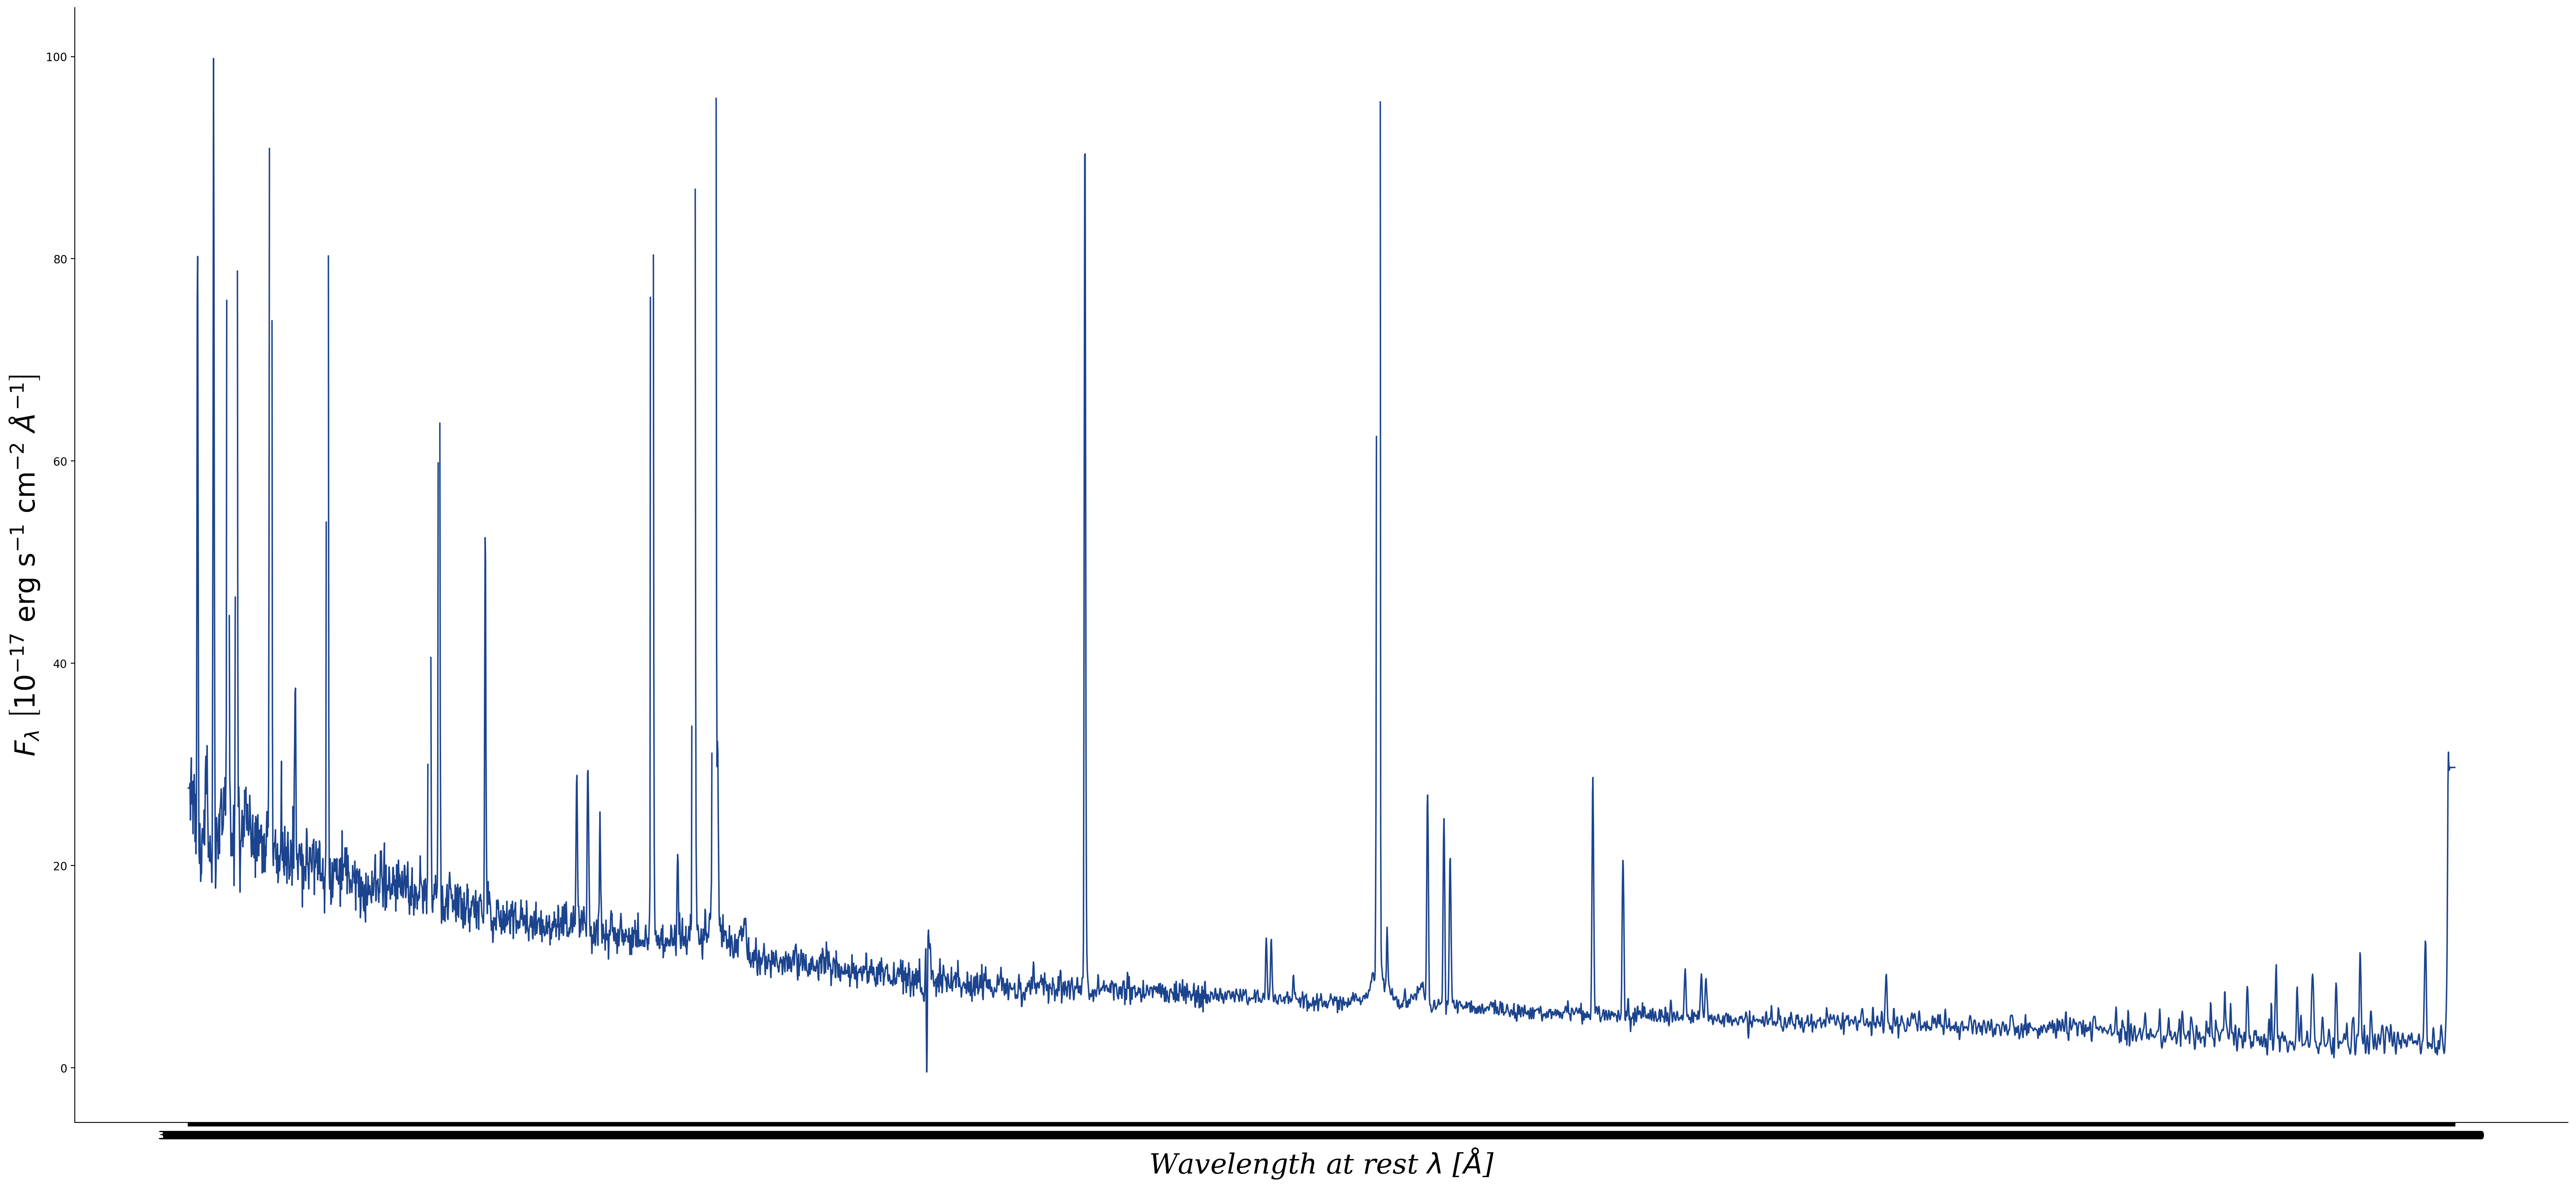

In [24]:
spec_plotter(spec_list[0])

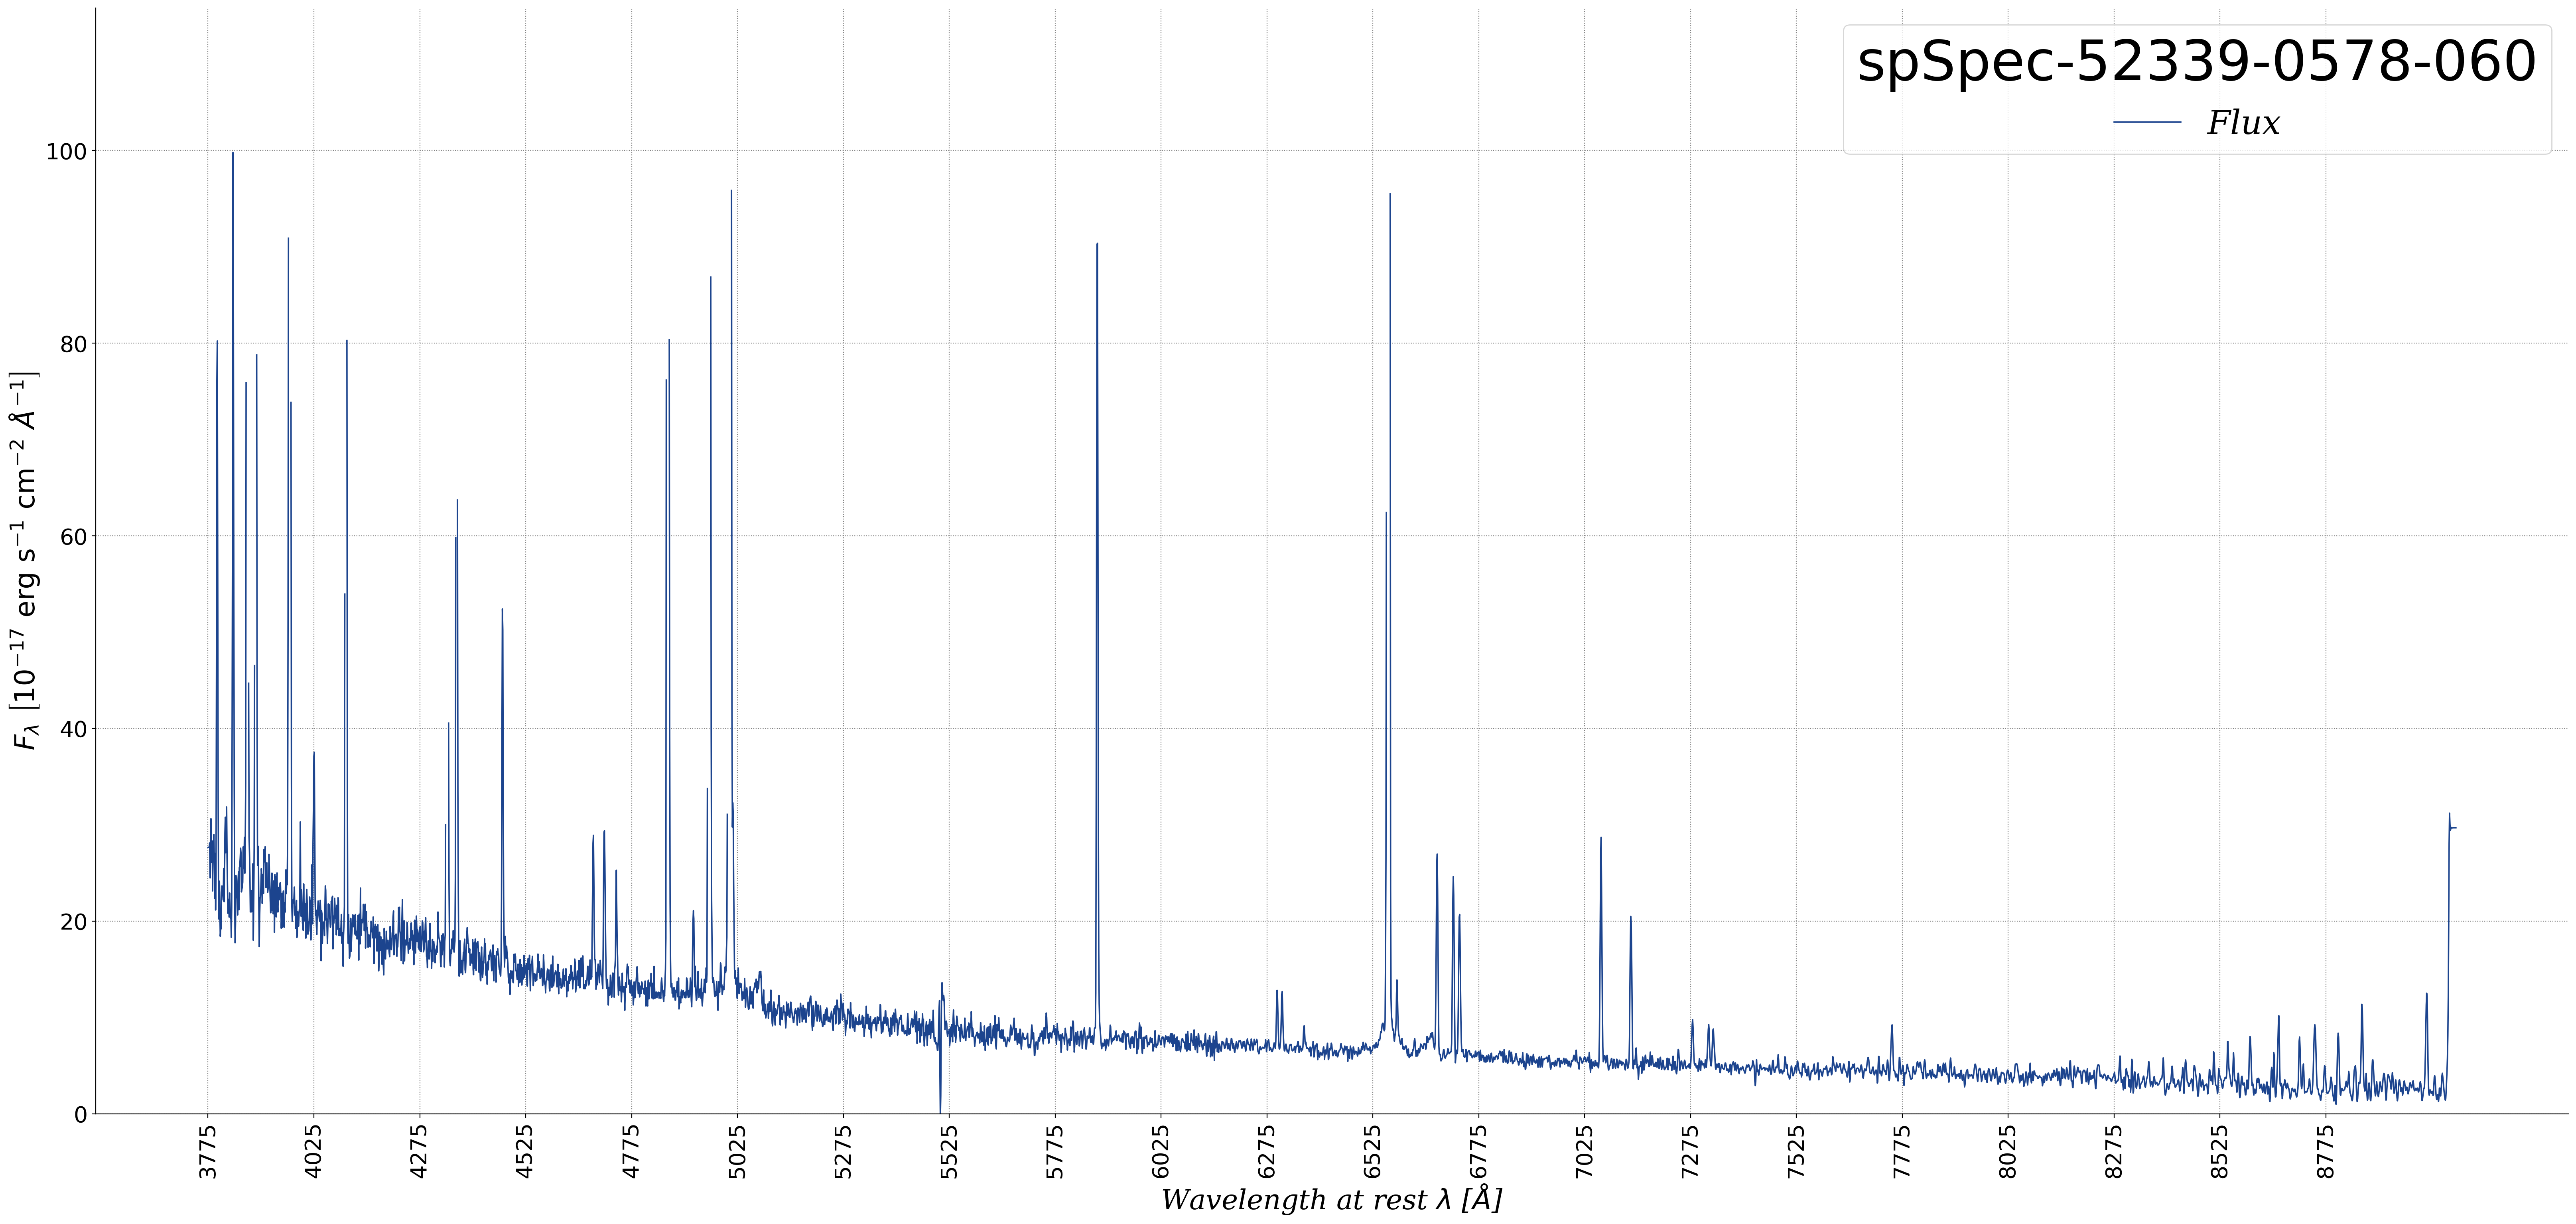

In [201]:
name = spec_list[0]
name = (name.replace('.fit',"")) + ".tex"
local_dirspc="/home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/Tex_spectra/"
spc = os.path.join(local_dirspc,name)
DF = pd.read_csv(spc,
                header=None, 
                sep='     ',
                engine = 'python',
                names = [r'$\lambda$','Flux'])

plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.figure(figsize=(40,18),dpi=200)
plt.plot(DF[r'$\lambda$'],DF['Flux'],label = 'Flux',lw=1.3, color ='#1C448E')
plt.ylabel(r"$F_{\lambda}\ \left[ 10^{-17}\ {\rm erg\ s}^{-1}\ {\rm cm}^{-2}\ \AA^{-1} \right]$", style = 'oblique', family = 'serif', size = 25)
plt.xlabel(r'Wavelength at rest $\lambda$ [$\AA$]', style = 'oblique', family = 'serif', size = 25)

N_ticks = np.arange(0,int(len(DF[r'$\lambda$'])/250),1)
ticks_f = lambda x: DF[r'$\lambda$'][x*250]
X_ticks = np.array(ticks_f(N_ticks))
X_label = []
for i in range(len(X_ticks)):
        X_label.append(X_ticks[i][0:-5])

plt.yticks(fontsize = 20)
plt.xticks(X_ticks,X_label,fontsize = 20,rotation=90)
plt.ylim(0,max(DF['Flux'],)+15)
plt.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.8)
txt_prop = {'style' : 'oblique', 'family' : 'serif', 'size' :30}       
plt.legend(title = f'{name[:-4]}', prop = txt_prop, loc= 'upper right', title_fontsize=50)
plt.show()
